### BUSINESS PROBLEM

Identify customers likely to disengage (churn proxy) and optimize retention strategies to improve conversion and reduce revenue loss.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
curr_dir = os.getcwd()
root = os.path.abspath(os.path.join(curr_dir, '..'))
data_dir = os.path.join(root, 'data')
raw_dir = os.path.join(data_dir, 'raw')
processed_dir = os.path.join(data_dir, 'processed')

In [3]:
print(curr_dir)
print(root)
print(data_dir)
print(raw_dir)
print(processed_dir)

c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_02\notebooks
c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_02
c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_02\data
c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_02\data\raw
c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_02\data\processed


In [4]:
try:
    df = pd.read_csv(os.path.join(raw_dir, 'TRAIN-HEALTH INSURANCE CROSS SELL PREDICTION.csv'))
    print("Data loaded successfully.")
except FileNotFoundError:
    print("File not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Data loaded successfully.


### Data Info

In [5]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [6]:
# 1. Basic Info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

Shape: (381109, 12)

Columns:
 Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')


In [7]:
# 2. Data Types
print("\nData Types:\n", df.dtypes)


Data Types:
 id                        int64
Gender                   object
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age              object
Vehicle_Damage           object
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object


In [8]:
# 3. Missing Values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
}).sort_values(by="Percentage", ascending=False)

display("Missing Values:", missing_df)

'Missing Values:'

,Missing Values,Percentage
id,0,0.0
Gender,0,0.0
Age,0,0.0
Driving_License,0,0.0
Region_Code,0,0.0
Previously_Insured,0,0.0
Vehicle_Age,0,0.0
Vehicle_Damage,0,0.0
Annual_Premium,0,0.0
Policy_Sales_Channel,0,0.0


In [9]:
# 4. Unique Values
print("\nUnique Values per Column:\n")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


Unique Values per Column:

id: 381109
Gender: 2
Age: 66
Driving_License: 2
Region_Code: 53
Previously_Insured: 2
Vehicle_Age: 3
Vehicle_Damage: 2
Annual_Premium: 48838
Policy_Sales_Channel: 155
Vintage: 290
Response: 2


In [10]:
# 5. Basic Statistics
display("Statistical Summary:", df.describe())

'Statistical Summary:'

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [11]:
# 6. Target Distribution
print("Target Distribution (Response):")
print(df['Response'].value_counts())
print()
print((df['Response'].value_counts(normalize=True) * 100)
      .reset_index(name='Percentage')
      .to_string(index=False))

Target Distribution (Response):
Response
0    334399
1     46710
Name: count, dtype: int64

 Response  Percentage
        0   87.743664
        1   12.256336


In [12]:
duplicate_rows = df[df.duplicated()]
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows (excluding 'id'): {duplicate_count}")
display(duplicate_rows)

Number of duplicate rows (excluding 'id'): 0


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response


### Data Cleaning

#### Basic Cleaning

In [13]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [14]:
df.shape

(381109, 12)

In [15]:
# 1. Drop ID
df = df.drop(columns=['id'])

In [16]:
# 2. Rename target
df.rename(columns={'Response': 'Churn'}, inplace=True)

In [17]:
df['Churn'] = df['Churn'].apply(lambda x: 0 if x == 1 else 1)

In [18]:
# 3. Convert categorical columns properly
cat_cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [19]:
# 4. Convert binary columns to category (important)
binary_cols = ['Driving_License', 'Previously_Insured', 'Churn']

for col in binary_cols:
    df[col] = df[col].astype('category')

In [20]:
# 5. Convert region and channel to category (VERY IMPORTANT)
df['Region_Code'] = df['Region_Code'].astype('category')
df['Policy_Sales_Channel'] = df['Policy_Sales_Channel'].astype('category')

In [21]:
# Final check
print(df.dtypes)

Gender                  category
Age                        int64
Driving_License         category
Region_Code             category
Previously_Insured      category
Vehicle_Age             category
Vehicle_Damage          category
Annual_Premium           float64
Policy_Sales_Channel    category
Vintage                    int64
Churn                   category
dtype: object


#### Outlier Detection and Removal

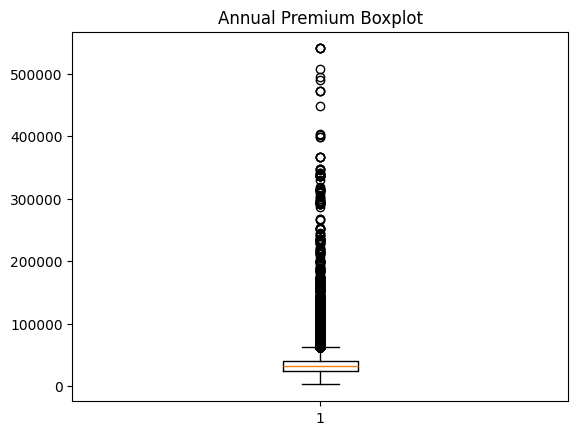

count    381109.000000
mean      30564.389581
std       17213.155057
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max      540165.000000
Name: Annual_Premium, dtype: float64


In [22]:
plt.boxplot(df['Annual_Premium'])
plt.title("Annual Premium Boxplot")
plt.show()

print(df['Annual_Premium'].describe())

In [23]:
# Check percentiles
p99 = df['Annual_Premium'].quantile(0.99)
p01 = df['Annual_Premium'].quantile(0.01)

print("1st percentile:", p01)
print("99th percentile:", p99)

1st percentile: 2630.0
99th percentile: 72963.0


In [24]:
# values outside 99th percentile and below 1st percentile
outliers = df[(df['Annual_Premium'] > p99) | (df['Annual_Premium'] < p01)]
print(f"Number of outliers in Annual_Premium: {len(outliers)}")

Number of outliers in Annual_Premium: 3810


In [25]:
# Percentage of outliers
outlier_percentage = (len(outliers) / len(df)) * 100
print(f"Percentage of outliers in Annual_Premium: {outlier_percentage:.2f}%")

Percentage of outliers in Annual_Premium: 1.00%


In [26]:
# Apply capping (Winsorization)
df['Annual_Premium'] = np.where(df['Annual_Premium'] > p99, p99, df['Annual_Premium'])
df['Annual_Premium'] = np.where(df['Annual_Premium'] < p01, p01, df['Annual_Premium'])
print(df['Annual_Premium'].describe())

count    381109.000000
mean      30338.717275
std       15916.679308
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max       72963.000000
Name: Annual_Premium, dtype: float64


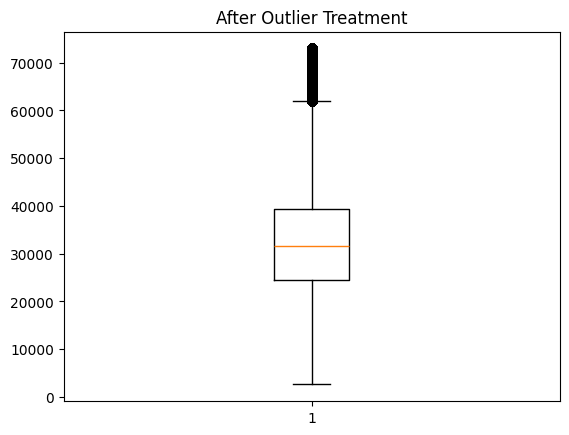

In [27]:
plt.boxplot(df['Annual_Premium'])
plt.title("After Outlier Treatment")
plt.show()


In [28]:
df.to_csv(os.path.join(processed_dir, "cleaned_data.csv"),index = False)